# Desafío - Fundamentos de análisis exploratorio y estadística descriptiva

**Contexto:** análisis exploratorio de ventas de videojuegos por región, plataforma, género y puntaje de crítica.

**Objetivo:** cumplir los requerimientos del desafío: carga del dataset, análisis exploratorio inicial (IDA), análisis descriptivo y univariado, visualizaciones e interpretación.

## 1. Generación y carga del conjunto de datos

Se cargará el archivo `06. videojuegos(1).csv` en un DataFrame de pandas llamado `df`.

In [2]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración para mostrar tablas con más claridad
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Carga del dataset
from pathlib import Path

rutas_posibles = [
    Path("analisis-exploratorio-videojuegos/data/videojuegos.csv"),
    Path("../data/videojuegos.csv"),
    Path("data/videojuegos.csv"),
]
ruta = next((ruta for ruta in rutas_posibles if ruta.exists()), None)
if ruta is None:
    raise FileNotFoundError(
        "No se encontró videojuegos.csv. Colócalo en "
        "analisis-exploratorio-videojuegos/data/videojuegos.csv"
    )

df = pd.read_csv(ruta)

# Vista rápida inicial
df.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.52,8.24,1.86,NaN
1,Juego_1,Nintendo,2019,Acción,9.53,3.67,3.88,97.00
2,Juego_2,PC,2021,Aventura,5.15,1.36,1.70,67.00
3,Juego_3,Xbox,2011,Estrategia,5.30,5.27,4.65,75.00
4,Juego_4,Xbox,2019,Estrategia,10.92,7.72,4.29,65.00


## 2. Análisis Exploratorio Inicial (IDA)

El IDA permite validar que los datos fueron cargados correctamente antes de profundizar en el análisis estadístico.

### 2.1 Primeras 5 filas

In [2]:
df.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.52,8.24,1.86,NaN
1,Juego_1,Nintendo,2019,Acción,9.53,3.67,3.88,97.00
2,Juego_2,PC,2021,Aventura,5.15,1.36,1.70,67.00
3,Juego_3,Xbox,2011,Estrategia,5.30,5.27,4.65,75.00
4,Juego_4,Xbox,2019,Estrategia,10.92,7.72,4.29,65.00


### 2.2 Últimas 5 filas

In [3]:
df.tail()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
95,Juego_95,PlayStation,2012,Acción,8.19,1.86,1.40,88.00
96,Juego_96,PlayStation,2015,RPG,4.37,7.53,4.75,79.00
97,Juego_97,Nintendo,2021,Acción,8.90,8.09,4.45,71.00
98,Juego_98,PlayStation,2011,Estrategia,0.55,9.91,2.28,73.00
99,Juego_99,PC,2019,Aventura,0.66,4.18,3.10,67.00


### 2.3 Información general del DataFrame

Con `.info()` revisamos columnas, cantidad de registros no nulos, tipos de datos y memoria utilizada.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    object 
 1   Plataforma        100 non-null    object 
 2   Anio_Lanzamiento  100 non-null    int64  
 3   Genero            100 non-null    object 
 4   Ventas_NA         100 non-null    float64
 5   Ventas_EU         100 non-null    float64
 6   Ventas_JP         100 non-null    float64
 7   Critica_Puntaje   90 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 6.4+ KB


### 2.4 Valores nulos por columna

In [5]:
nulos = df.isnull().sum().to_frame(name='Cantidad de nulos')
nulos['Porcentaje de nulos'] = (df.isnull().mean() * 100).round(2)
nulos

,Cantidad de nulos,Porcentaje de nulos
Nombre,0,0.00
Plataforma,0,0.00
Anio_Lanzamiento,0,0.00
Genero,0,0.00
Ventas_NA,0,0.00
Ventas_EU,0,0.00
Ventas_JP,0,0.00
Critica_Puntaje,10,10.00


### 2.5 Tipos de datos por columna

In [3]:
df.dtypes.to_frame(name='Tipo de dato')

,Tipo de dato
Nombre,str
Plataforma,str
Anio_Lanzamiento,int64
Genero,str
Ventas_NA,float64
Ventas_EU,float64
Ventas_JP,float64
Critica_Puntaje,float64


### 2.6 Dimensiones del DataFrame

In [4]:
filas, columnas = df.shape
print(f'El DataFrame tiene {filas} filas y {columnas} columnas.')

El DataFrame tiene 100 filas y 8 columnas.


### Interpretación del IDA

El dataset se cargó correctamente y contiene **100 registros y 8 columnas**. Las columnas `Nombre`, `Plataforma` y `Genero` son categóricas; `Anio_Lanzamiento` es numérica entera; y `Ventas_NA`, `Ventas_EU`, `Ventas_JP` y `Critica_Puntaje` son numéricas.

Se observan **10 valores nulos en `Critica_Puntaje`**, equivalentes al 10% del total. Las columnas de ventas no presentan valores nulos, por lo que pueden analizarse directamente.

## 3. Análisis descriptivo y univariado

En esta sección se analizan variables individuales, separando variables numéricas y categóricas.

### 3.1 Medidas de tendencia central y dispersión

Se calculan media, mediana, desviación estándar y rango para las variables solicitadas.

In [6]:
columnas_numericas = ['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje']

resumen = pd.DataFrame({
    'Media': df[columnas_numericas].mean(),
    'Mediana': df[columnas_numericas].median(),
    'Desviación estándar': df[columnas_numericas].std(),
    'Mínimo': df[columnas_numericas].min(),
    'Máximo': df[columnas_numericas].max()
})

resumen['Rango'] = resumen['Máximo'] - resumen['Mínimo']
resumen.round(2)

,Media,Mediana,Desviación estándar,Mínimo,Máximo,Rango
Ventas_NA,8.11,8.71,4.36,0.18,14.85,14.68
Ventas_EU,4.80,5.02,2.90,0.24,9.91,9.66
Ventas_JP,2.65,2.76,1.57,0.05,4.96,4.91
Critica_Puntaje,68.70,68.50,17.87,40.00,99.00,59.00


### Interpretación de las medidas descriptivas

- `Ventas_NA` presenta la media de ventas más alta entre las regiones, por lo que Norteamérica parece ser el mercado más fuerte del conjunto de datos.
- `Ventas_EU` tiene ventas promedio intermedias.
- `Ventas_JP` muestra la media más baja, lo que indica menor volumen de ventas en esta región.
- En `Critica_Puntaje`, la media y la mediana son muy similares, lo que sugiere una distribución relativamente equilibrada alrededor del centro.
- Las desviaciones estándar permiten comparar la variabilidad: `Ventas_NA` muestra mayor dispersión absoluta que `Ventas_EU` y `Ventas_JP`.

### 3.2 Histogramas

Se generan histogramas para `Ventas_NA` y `Critica_Puntaje`, tal como solicita el desafío.

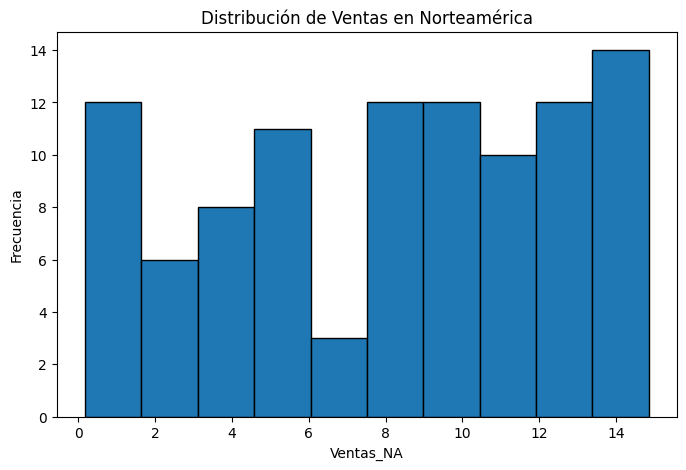

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['Ventas_NA'], bins=10, edgecolor='black')
plt.title('Distribución de Ventas en Norteamérica')
plt.xlabel('Ventas_NA')
plt.ylabel('Frecuencia')
plt.show()

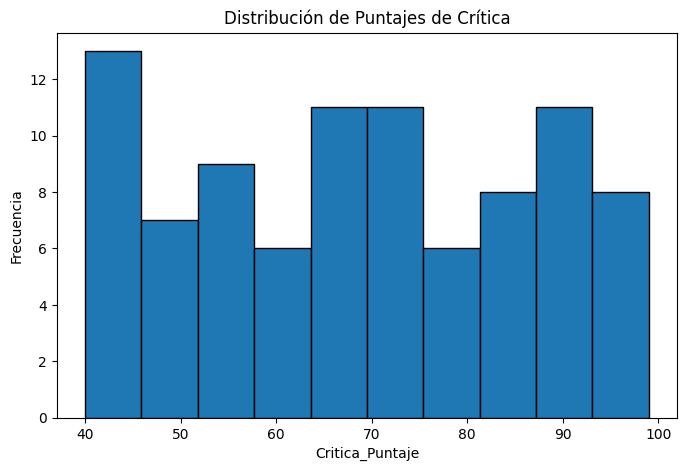

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['Critica_Puntaje'].dropna(), bins=10, edgecolor='black')
plt.title('Distribución de Puntajes de Crítica')
plt.xlabel('Critica_Puntaje')
plt.ylabel('Frecuencia')
plt.show()

### Observaciones sobre los histogramas

- En `Ventas_NA`, los valores se distribuyen a lo largo de un rango amplio, desde ventas muy bajas hasta ventas cercanas al máximo del conjunto. Esto indica que no todos los videojuegos tienen el mismo desempeño comercial en Norteamérica.
- En `Critica_Puntaje`, los puntajes se concentran entre valores medios y altos, aunque existen juegos con puntajes bajos. Para graficar esta variable se excluyeron temporalmente los valores nulos con `.dropna()`.

### 3.3 Diagramas de caja por región

Los boxplots permiten observar la mediana, el rango intercuartílico y posibles valores atípicos.

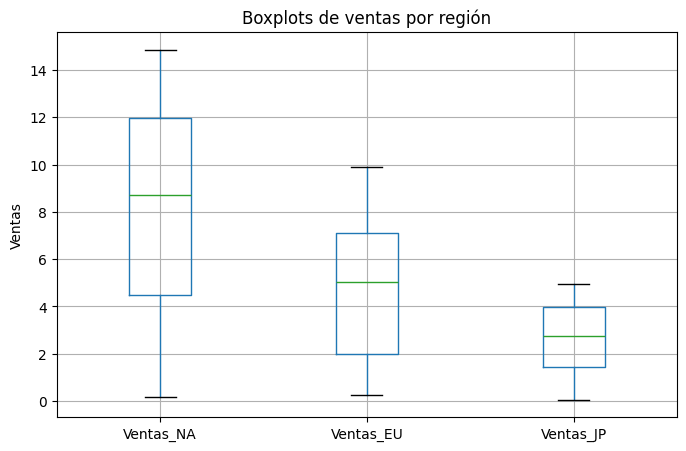

In [11]:
plt.figure(figsize=(8, 5))
df[['Ventas_NA', 'Ventas_EU', 'Ventas_JP']].boxplot()
plt.title('Boxplots de ventas por región')
plt.ylabel('Ventas')
plt.show()

In [7]:
# Detección numérica de outliers usando el criterio IQR
ventas_region = ['Ventas_NA', 'Ventas_EU', 'Ventas_JP']
resultado_outliers = []

for columna in ventas_region:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)].shape[0]

    resultado_outliers.append({
        'Variable': columna,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Límite inferior': limite_inferior,
        'Límite superior': limite_superior,
        'Cantidad de outliers': cantidad_outliers
    })

pd.DataFrame(resultado_outliers).round(2)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers
0,Ventas_NA,4.48,11.95,7.46,-6.71,23.14,0
1,Ventas_EU,1.99,7.09,5.10,-5.66,14.74,0
2,Ventas_JP,1.46,3.98,2.53,-2.33,7.78,0


### Interpretación de los boxplots

Según el criterio del rango intercuartílico (IQR), **no se detectan valores atípicos en las ventas regionales**. Esto significa que, aunque existen diferencias entre videojuegos, los valores se mantienen dentro de límites esperables para cada región.

### 3.4 Tablas de frecuencia para variables categóricas

Se cuentan los videojuegos por `Plataforma` y por `Genero`.

In [9]:
frecuencia_plataforma = df['Plataforma'].value_counts().to_frame(name='Cantidad')
frecuencia_plataforma['Porcentaje'] = (df['Plataforma'].value_counts(normalize=True) * 100).round(2)
frecuencia_plataforma

,Cantidad,Porcentaje
Plataforma,,
Nintendo,30,30.00
PlayStation,26,26.00
Xbox,24,24.00
PC,20,20.00


In [11]:
frecuencia_genero = df['Genero'].value_counts().to_frame(name='Cantidad')
frecuencia_genero['Porcentaje'] = (df['Genero'].value_counts(normalize=True) * 100).round(2)
frecuencia_genero

,Cantidad,Porcentaje
Genero,,
Acción,29,29.00
Estrategia,26,26.00
Deportes,20,20.00
RPG,15,15.00
Aventura,10,10.00


### 3.5 Gráfico de barras por género

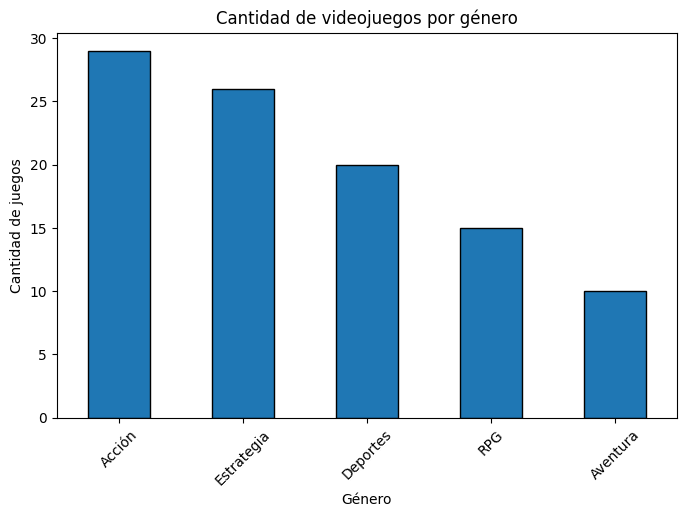

In [15]:
plt.figure(figsize=(8, 5))
df['Genero'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Cantidad de videojuegos por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45)
plt.show()

In [12]:
genero_mas_comun = df['Genero'].value_counts().idxmax()
cantidad_genero_mas_comun = df['Genero'].value_counts().max()

print(f'El género más común es {genero_mas_comun}, con {cantidad_genero_mas_comun} videojuegos.')

El género más común es Acción, con 29 videojuegos.


### Interpretación de variables categóricas

La plataforma con mayor cantidad de videojuegos es **Nintendo**, mientras que el género más frecuente es **Acción**, con 29 juegos. Esto puede orientar futuras estrategias de marketing, ya que el género Acción tiene mayor representación dentro del conjunto de datos.

## 4. Conclusión general

El análisis exploratorio permitió conocer la estructura del dataset, identificar valores nulos, clasificar variables y estudiar el comportamiento de las ventas por región. Norteamérica destaca como la región con mayores ventas promedio, mientras que Japón presenta los valores más bajos. No se detectaron valores atípicos en las ventas regionales utilizando el criterio IQR.

Desde el punto de vista comercial, el género **Acción** y la plataforma **Nintendo** son categorías relevantes por su mayor presencia en el dataset. Estos hallazgos pueden servir como base para decisiones de marketing, segmentación y análisis posteriores más avanzados.